# KBO FA 연봉 예측 — StoveLens AI
## clean_model_train.ipynb

**목표**: KBO FA 선수의 최근 3년 성적 + 스타성 지표를 바탕으로 연평균 연봉 예측
**분리 모델**: 타자 / 투수 각각 별도 학습
**사용 기법**: LinearRegression · RandomForestRegressor · XGBRegressor
**평가 지표**: R² · MSE · RMSE · MAE

## 0. 라이브러리 임포트 및 환경 설정

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from IPython.display import display

try:
    import koreanize_matplotlib
except ImportError:
    print("⚠️  koreanize-matplotlib 없음 — pip install koreanize-matplotlib")

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

BASE   = Path('..')
DATA   = BASE / 'data'
MODELS = BASE / 'models'
MODELS.mkdir(exist_ok=True)

# 데이터 누수 컬럼 — 모델 입력 절대 제외
LEAKAGE = ['player_name', 'position', 'team', 'contract_years', 'total_contract_amount']
TARGET  = 'annual_avg_salary'

def get_metrics(y_true, y_pred, name=''):
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    return {'모델': name, 'R²': round(r2, 4), 'MSE': round(mse, 4),
            'RMSE': round(rmse, 4), 'MAE': round(mae, 4)}

print("✅ 환경 설정 완료")

⚠️  koreanize-matplotlib 없음 — pip install koreanize-matplotlib
✅ 환경 설정 완료


## 1. 데이터 로드 및 학습 데이터 v5 생성

### 1-1. 타자 학습 데이터 v5 (스타성 변수 추가)

In [2]:
h4 = pd.read_csv(DATA / 'hitter_training_v4.csv')
print(f"타자 v4 로드: {h4.shape}")

v5_path = DATA / 'hitter_training_v5.csv'
if v5_path.exists():
    h5 = pd.read_csv(v5_path)
    print(f"타자 v5 기존 파일 로드: {h5.shape}")
else:
    h5 = h4.copy()
    # 스타성 변수 추가 (기본 0 — 추후 수동 입력)
    for col in ['mvp_count', 'golden_glove_count', 'allstar_count',
                'national_team', 'postseason_experience']:
        h5[col] = 0
    # star_score: MVP×5, 골든글러브×3, 국가대표×2, 올스타×1, 포스트시즌×1
    h5['star_score'] = (
        h5['mvp_count'] * 5 + h5['golden_glove_count'] * 3 +
        h5['national_team'] * 2 + h5['allstar_count'] + h5['postseason_experience']
    )
    h5.to_csv(v5_path, index=False, encoding='utf-8-sig')
    print(f"타자 v5 생성 완료: {h5.shape}")

print(f"v4 대비 추가 컬럼: {[c for c in h5.columns if c not in h4.columns]}")
display(h5[['player_name', 'fa_year', 'age_at_fa', 'war_3yr_sum',
            'star_score', TARGET]].head(5))

타자 v4 로드: (80, 36)
타자 v5 기존 파일 로드: (80, 42)
v4 대비 추가 컬럼: ['mvp_count', 'golden_glove_count', 'allstar_count', 'national_team', 'postseason_experience', 'star_score']


,player_name,fa_year,age_at_fa,war_3yr_sum,star_score,annual_avg_salary
0,민병헌,2018,31,3.14,11,20.00
1,황재균,2018,31,0.00,11,22.00
2,정근우,2018,36,3.05,12,11.67
3,손아섭,2018,32,6.28,16,24.50
4,강민호,2018,33,2.36,28,20.00


### 1-2. 투수 학습 데이터 v5 (pitcher_role 추가)

In [3]:
p4 = pd.read_csv(DATA / 'pitcher_training_v4.csv')
print(f"투수 v4 로드: {p4.shape}")

p5_path = DATA / 'pitcher_training_v5.csv'
if p5_path.exists():
    p5 = pd.read_csv(p5_path)
    print(f"투수 v5 기존 파일 로드: {p5.shape}")
else:
    p5 = p4.copy()
    for col in ['mvp_count', 'golden_glove_count', 'allstar_count',
                'national_team', 'postseason_experience']:
        p5[col] = 0
    p5['star_score'] = (
        p5['mvp_count'] * 5 + p5['golden_glove_count'] * 3 +
        p5['national_team'] * 2 + p5['allstar_count'] + p5['postseason_experience']
    )
    # pitcher_role 분류: save_3yr_avg>=10 → CL, hold_3yr_avg>=10 → SU, 그외 → SP
    def classify_role(row):
        if row['save_3yr_avg'] >= 10:
            return 'CL'
        elif row['hold_3yr_avg'] >= 10:
            return 'SU'
        else:
            return 'SP'
    p5['pitcher_role'] = p5.apply(classify_role, axis=1)
    p5.to_csv(p5_path, index=False, encoding='utf-8-sig')
    print(f"투수 v5 생성 완료: {p5.shape}")

print("\npitcher_role 분포:")
print(p5['pitcher_role'].value_counts())
display(p5[['player_name', 'fa_year', 'pitcher_role',
            'save_3yr_avg', 'hold_3yr_avg', 'era_3yr_avg', TARGET]].head(6))

투수 v4 로드: (43, 22)
투수 v5 기존 파일 로드: (43, 29)

pitcher_role 분포:
pitcher_role
SP    30
SU     8
CL     5
Name: count, dtype: int64


,player_name,fa_year,pitcher_role,save_3yr_avg,hold_3yr_avg,era_3yr_avg,annual_avg_salary
0,안영명,2018,SP,0.000000,0.500000,12.674200,6.00
1,박정진,2018,SP,0.666667,9.333333,4.200893,3.75
2,김승회,2018,SP,0.666667,5.666667,5.704777,1.50
3,권오준,2018,SP,0.000000,2.666667,5.687820,3.00
4,윤성환,2019,SP,0.000000,0.000000,5.205000,10.00
5,이보근,2019,SU,2.000000,22.333333,4.733550,4.75


## 2. 탐색적 데이터 분석 (EDA)

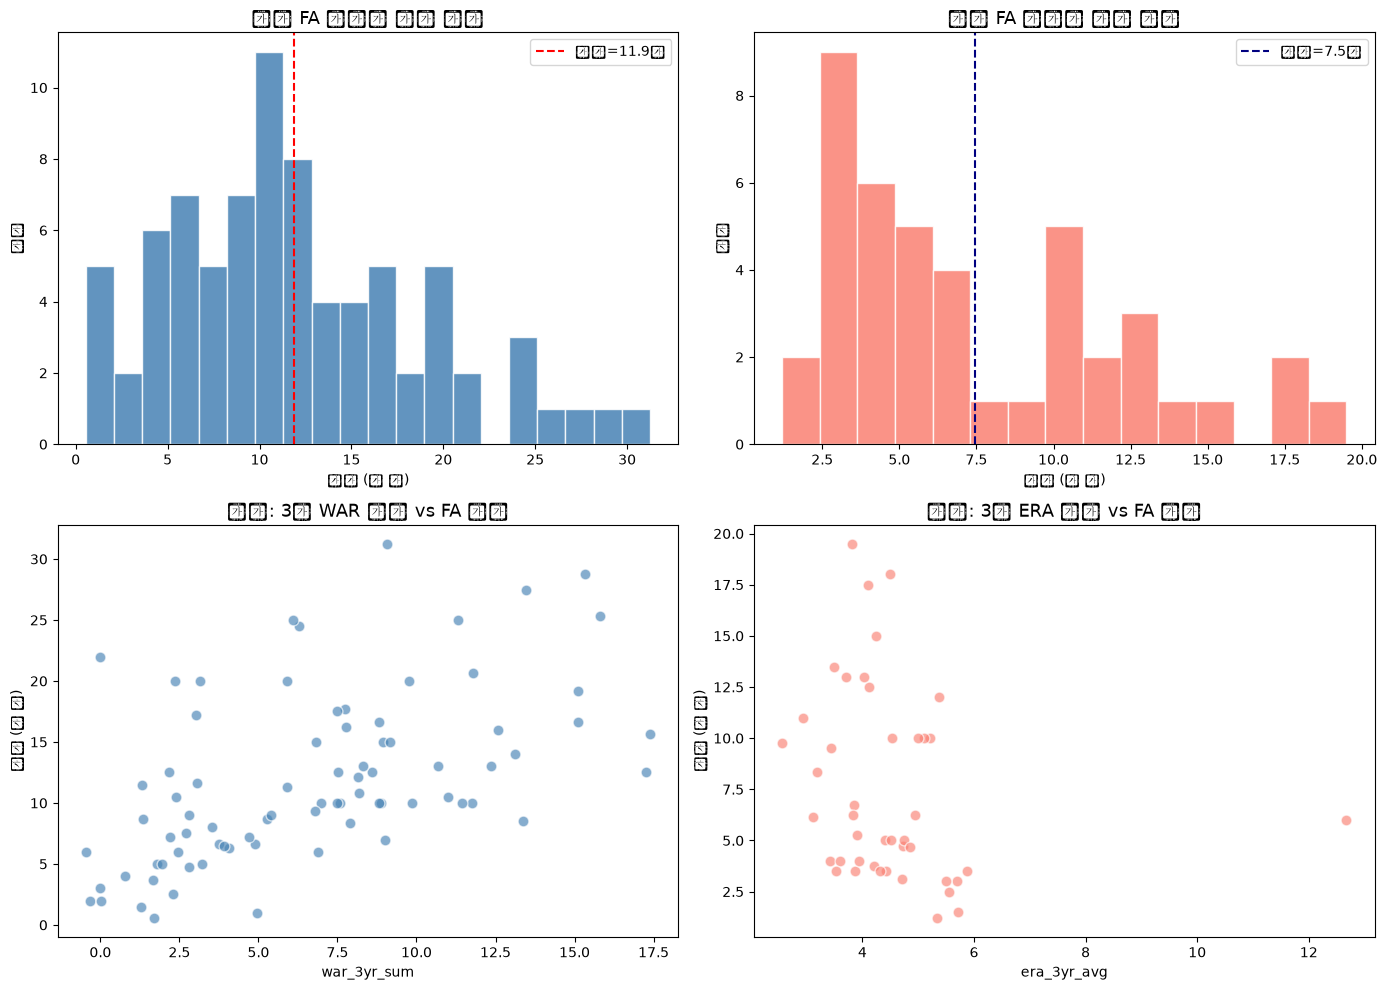

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(h5[TARGET], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('타자 FA 연평균 연봉 분포', fontsize=13)
axes[0, 0].set_xlabel('연봉 (억 원)')
axes[0, 0].set_ylabel('빈도')
axes[0, 0].axvline(h5[TARGET].mean(), color='red', linestyle='--',
                   label=f"평균={h5[TARGET].mean():.1f}억")
axes[0, 0].legend()

axes[0, 1].hist(p5[TARGET], bins=15, color='salmon', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('투수 FA 연평균 연봉 분포', fontsize=13)
axes[0, 1].set_xlabel('연봉 (억 원)')
axes[0, 1].set_ylabel('빈도')
axes[0, 1].axvline(p5[TARGET].mean(), color='navy', linestyle='--',
                   label=f"평균={p5[TARGET].mean():.1f}억")
axes[0, 1].legend()

axes[1, 0].scatter(h5['war_3yr_sum'], h5[TARGET],
                   alpha=0.65, color='steelblue', edgecolors='white', s=60)
axes[1, 0].set_title('타자: 3년 WAR 합계 vs FA 연봉', fontsize=13)
axes[1, 0].set_xlabel('war_3yr_sum')
axes[1, 0].set_ylabel('연봉 (억 원)')

axes[1, 1].scatter(p5['era_3yr_avg'], p5[TARGET],
                   alpha=0.65, color='salmon', edgecolors='white', s=60)
axes[1, 1].set_title('투수: 3년 ERA 평균 vs FA 연봉', fontsize=13)
axes[1, 1].set_xlabel('era_3yr_avg')
axes[1, 1].set_ylabel('연봉 (억 원)')

plt.tight_layout()
plt.show()

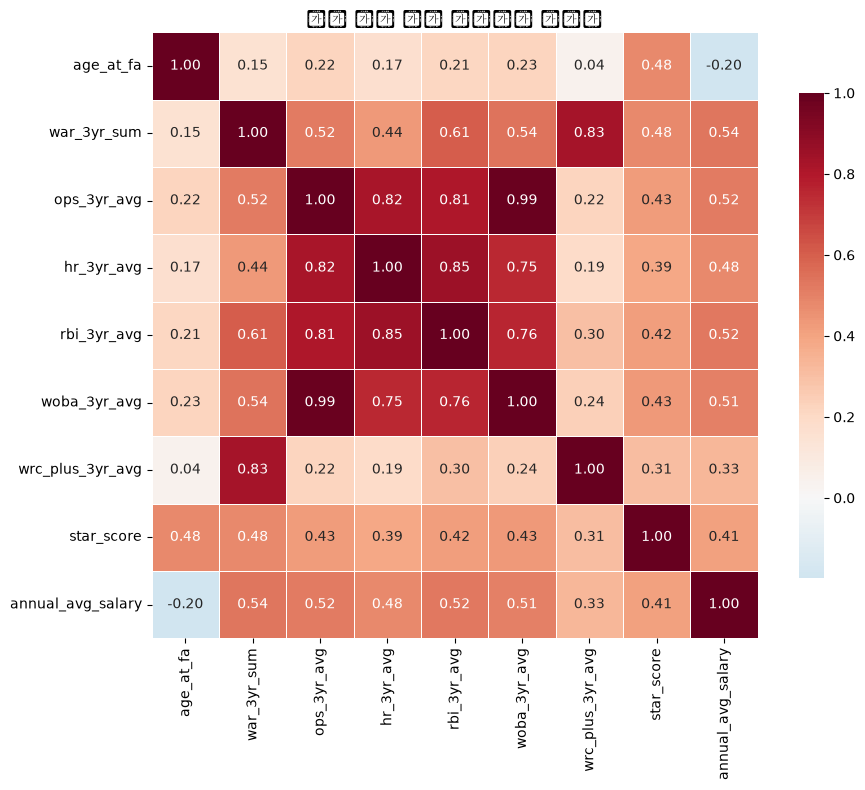

In [5]:
# 타자 주요 피처 상관관계 히트맵
h_corr_cols = ['age_at_fa', 'war_3yr_sum', 'ops_3yr_avg', 'hr_3yr_avg',
               'rbi_3yr_avg', 'woba_3yr_avg', 'wrc_plus_3yr_avg', 'star_score', TARGET]
corr = h5[h_corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('타자 주요 피처 상관관계 히트맵', fontsize=13)
plt.tight_layout()
plt.show()

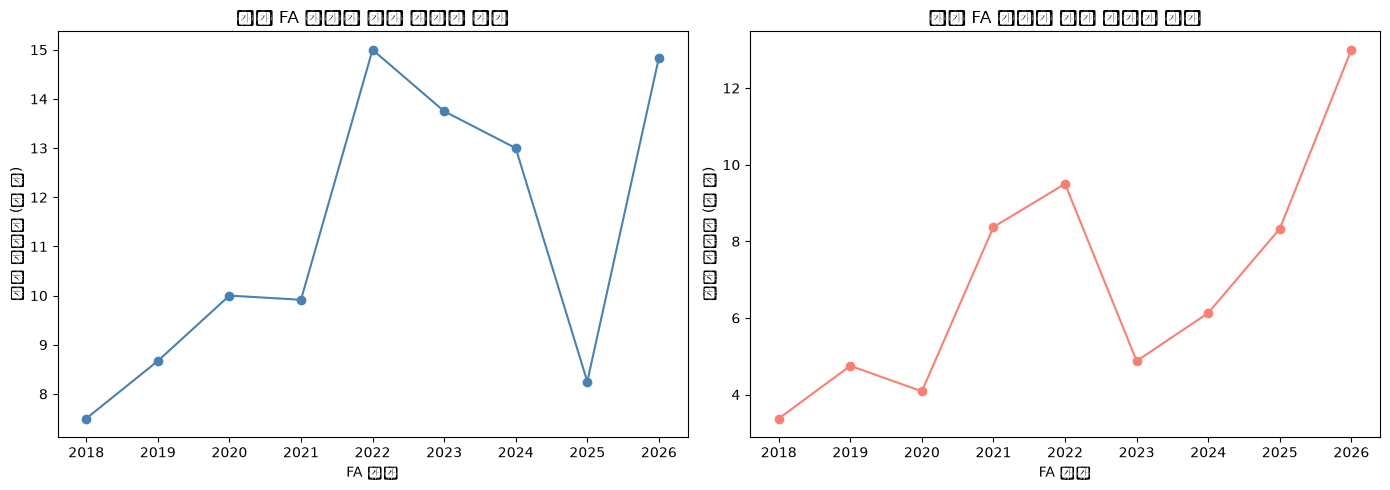

In [6]:
# FA 연도별 연봉 추이
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

h5.groupby('fa_year')[TARGET].median().plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('타자 FA 연도별 연봉 중앙값 추이', fontsize=12)
axes[0].set_xlabel('FA 연도')
axes[0].set_ylabel('연봉 중앙값 (억 원)')

p5.groupby('fa_year')[TARGET].median().plot(ax=axes[1], marker='o', color='salmon')
axes[1].set_title('투수 FA 연도별 연봉 중앙값 추이', fontsize=12)
axes[1].set_xlabel('FA 연도')
axes[1].set_ylabel('연봉 중앙값 (억 원)')

plt.tight_layout()
plt.show()

## 3. 타자 모델링

**데이터 누수 제외**: `player_name`, `position`, `team`, `contract_years`, `total_contract_amount`
**예측 타깃**: `annual_avg_salary` (억 원)

In [7]:
h_feature_cols = [c for c in h5.columns if c not in LEAKAGE + [TARGET]]
print(f"타자 전체 피처 ({len(h_feature_cols)}개):")
for c in h_feature_cols:
    print(f"  {c}")

타자 전체 피처 (36개):
  fa_year
  age_at_fa
  games_3yr_avg
  ab_3yr_avg
  avg_3yr_avg
  obp_3yr_avg
  slg_3yr_avg
  ops_3yr_avg
  isop_3yr_avg
  babip_3yr_avg
  woba_3yr_avg
  wrc_plus_3yr_avg
  hr_3yr_avg
  rbi_3yr_avg
  run_3yr_avg
  hit_3yr_avg
  double_3yr_avg
  triple_3yr_avg
  bb_3yr_avg
  hp_3yr_avg
  kk_3yr_avg
  sb_3yr_avg
  cs_3yr_avg
  gd_3yr_avg
  wpa_3yr_avg
  war_3yr_avg
  war_3yr_sum
  war_last_year
  ops_last_year
  wrc_plus_last_year
  mvp_count
  golden_glove_count
  allstar_count
  national_team
  postseason_experience
  star_score


### 3-1. fa_year 포함 vs 제외 실험 (5-Fold CV)

In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fa_exp_h = []

for include_fa in [True, False]:
    cols = h_feature_cols if include_fa else [c for c in h_feature_cols if c != 'fa_year']
    X = h5[cols].fillna(0)
    y = h5[TARGET]

    for name, model in [
        ('LinearRegression', LinearRegression()),
        ('RandomForest', RandomForestRegressor(n_estimators=100, random_state=42)),
        ('XGBoost', XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                                 random_state=42, verbosity=0))
    ]:
        r2s   = cross_val_score(model, X, y, cv=kf, scoring='r2')
        rmses = cross_val_score(model, X, y, cv=kf,
                                scoring='neg_root_mean_squared_error')
        maes  = cross_val_score(model, X, y, cv=kf,
                                scoring='neg_mean_absolute_error')
        fa_exp_h.append({
            'fa_year': '포함' if include_fa else '제외',
            '모델': name,
            'R² (CV평균)':   round(r2s.mean(), 4),
            'RMSE (CV평균)': round(-rmses.mean(), 4),
            'MAE (CV평균)':  round(-maes.mean(), 4)
        })

df_fa_h = pd.DataFrame(fa_exp_h)
print("=== 타자: fa_year 포함 vs 제외 비교 (5-Fold CV) ===")
display(df_fa_h.pivot_table(
    index='모델', columns='fa_year',
    values=['R² (CV평균)', 'RMSE (CV평균)', 'MAE (CV평균)']
))

=== 타자: fa_year 포함 vs 제외 비교 (5-Fold CV) ===


MAE (CV평균)         RMSE (CV평균)         R² (CV평균)        
fa_year                  제외      포함          제외      포함        제외      포함
모델                                                                       
LinearRegression     5.4815  5.1304      6.8513  6.4860   -0.1086  0.0070
RandomForest         4.2266  4.2316      5.2943  5.2698    0.3421  0.3507
XGBoost              4.5421  4.4631      5.5835  5.5583    0.2868  0.2866

### 3-2. 최종 모델 학습 (fa_year 제외)

In [9]:
h_final_cols = [c for c in h_feature_cols if c != 'fa_year']
X_h = h5[h_final_cols].fillna(0)
y_h = h5[TARGET]

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)
print(f"타자 train: {X_train_h.shape}, test: {X_test_h.shape}")
print(f"연봉: 평균={y_h.mean():.1f}억  중앙값={y_h.median():.1f}억  최대={y_h.max():.1f}억")

models_h = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=42, verbosity=0)
}

results_h = []
preds_h   = {}

for name, model in models_h.items():
    model.fit(X_train_h, y_train_h)
    y_pred = model.predict(X_test_h)
    preds_h[name] = y_pred
    results_h.append(get_metrics(y_test_h, y_pred, name))
    print(f"  [{name}] 완료")

df_results_h = pd.DataFrame(results_h).set_index('모델')
print("\n=== 타자 모델 성능 비교 (R², MSE, RMSE, MAE) ===")
display(df_results_h)

타자 train: (64, 35), test: (16, 35)
연봉: 평균=11.9억  중앙값=10.2억  최대=31.2억
  [LinearRegression] 완료
  [RandomForest] 완료
  [XGBoost] 완료

=== 타자 모델 성능 비교 (R², MSE, RMSE, MAE) ===


,R²,MSE,RMSE,MAE
모델,,,,
LinearRegression,0.1440,50.1421,7.0811,6.0043
RandomForest,0.4057,34.8120,5.9002,4.7375
XGBoost,0.4877,30.0113,5.4783,4.2721


### 3-3. 실제값 vs 예측값 산점도

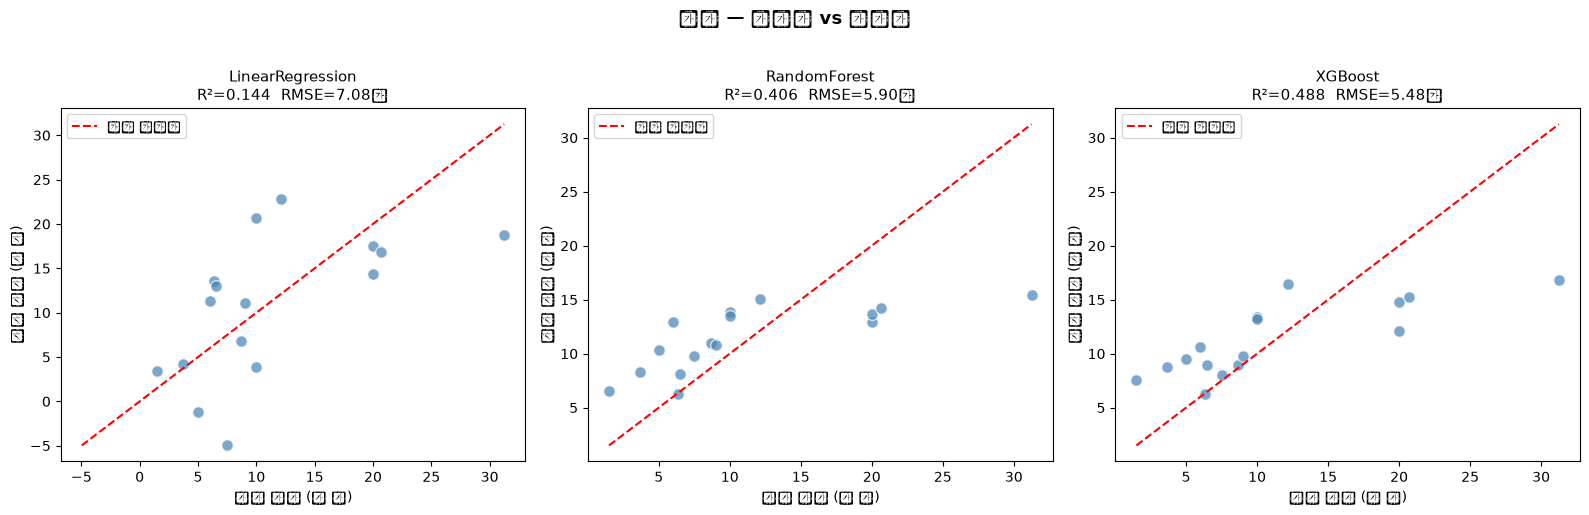

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (name, y_pred) in enumerate(preds_h.items()):
    ax = axes[i]
    ax.scatter(y_test_h, y_pred, alpha=0.7, color='steelblue',
               edgecolors='white', s=70)
    mn = min(float(y_test_h.min()), float(y_pred.min()))
    mx = max(float(y_test_h.max()), float(y_pred.max()))
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='완벽 예측선')
    r2   = r2_score(y_test_h, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_h, y_pred))
    ax.set_title(f'{name}\nR²={r2:.3f}  RMSE={rmse:.2f}억', fontsize=11)
    ax.set_xlabel('실제 연봉 (억 원)')
    ax.set_ylabel('예측 연봉 (억 원)')
    ax.legend(fontsize=9)

plt.suptitle('타자 — 실제값 vs 예측값', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3-4. Feature Importance

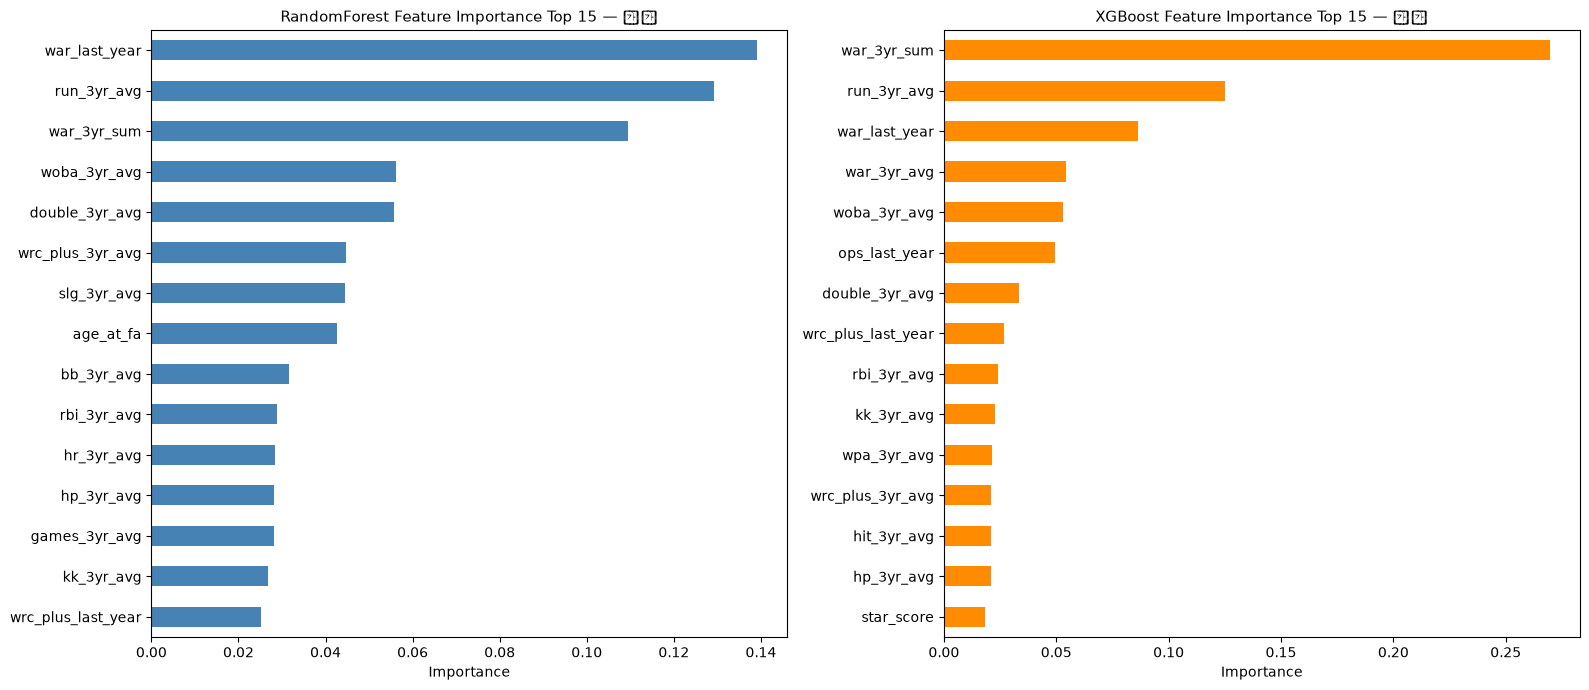

XGBoost Top 10 피처 (타자):
  war_3yr_sum                    0.2696
  run_3yr_avg                    0.1251
  war_last_year                  0.0864
  war_3yr_avg                    0.0542
  woba_3yr_avg                   0.0532
  ops_last_year                  0.0496
  double_3yr_avg                 0.0336
  wrc_plus_last_year             0.0268
  rbi_3yr_avg                    0.0239
  kk_3yr_avg                     0.0227
  wpa_3yr_avg                    0.0216
  wrc_plus_3yr_avg               0.0212
  hit_3yr_avg                    0.0209
  hp_3yr_avg                     0.0209
  star_score                     0.0183


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

rf_h  = models_h['RandomForest']
xgb_h = models_h['XGBoost']

imp_rf_h = (pd.Series(rf_h.feature_importances_, index=h_final_cols)
            .sort_values(ascending=False)[:15])
imp_rf_h[::-1].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('RandomForest Feature Importance Top 15 — 타자', fontsize=11)
axes[0].set_xlabel('Importance')

imp_xgb_h = (pd.Series(xgb_h.feature_importances_, index=h_final_cols)
             .sort_values(ascending=False)[:15])
imp_xgb_h[::-1].plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('XGBoost Feature Importance Top 15 — 타자', fontsize=11)
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("XGBoost Top 10 피처 (타자):")
for feat, val in imp_xgb_h.items():
    print(f"  {feat:<30} {val:.4f}")

## 4. 투수 모델링

**인코딩**: `pitcher_role` (SP/SU/CL) → LabelEncoder 확인 후 pd.get_dummies 적용

### 4-1. pitcher_role 인코딩

In [12]:
# LabelEncoder (수업 커리큘럼 방식)
le = LabelEncoder()
p5_enc = p5.copy()
p5_enc['pitcher_role_encoded'] = le.fit_transform(p5_enc['pitcher_role'])
print("LabelEncoder 인코딩 결과:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# pd.get_dummies — 원핫인코딩 (실제 모델 입력에 사용)
p5_dummies = pd.get_dummies(p5_enc, columns=['pitcher_role'], drop_first=True)
role_dummy_cols = [c for c in p5_dummies.columns if c.startswith('pitcher_role_')]
print(f"\n원핫인코딩 생성 컬럼: {role_dummy_cols}")

display(p5_dummies[['player_name', 'pitcher_role_encoded']
                   + role_dummy_cols + [TARGET]].head(6))

LabelEncoder 인코딩 결과:
{'CL': np.int64(0), 'SP': np.int64(1), 'SU': np.int64(2)}

원핫인코딩 생성 컬럼: ['pitcher_role_encoded', 'pitcher_role_SP', 'pitcher_role_SU']


,player_name,pitcher_role_encoded,pitcher_role_encoded,pitcher_role_SP,pitcher_role_SU,annual_avg_salary
0,안영명,1,1,True,False,6.00
1,박정진,1,1,True,False,3.75
2,김승회,1,1,True,False,1.50
3,권오준,1,1,True,False,3.00
4,윤성환,1,1,True,False,10.00
5,이보근,2,2,False,True,4.75


In [13]:
LEAKAGE_P = LEAKAGE + ['pitcher_role', 'pitcher_role_encoded']
p_feature_cols = [c for c in p5_dummies.columns if c not in LEAKAGE_P + [TARGET]]
print(f"투수 피처 ({len(p_feature_cols)}개):")
for c in p_feature_cols:
    print(f"  {c}")

투수 피처 (24개):
  fa_year
  age_at_fa
  games_3yr_avg
  innings_3yr_avg
  era_3yr_avg
  whip_3yr_avg
  win_3yr_avg
  lose_3yr_avg
  save_3yr_avg
  hold_3yr_avg
  hit_allowed_3yr_avg
  war_3yr_avg
  war_3yr_sum
  war_last_year
  era_last_year
  whip_last_year
  mvp_count
  golden_glove_count
  allstar_count
  national_team
  postseason_experience
  star_score
  pitcher_role_SP
  pitcher_role_SU


### 4-2. fa_year 포함 vs 제외 실험 (5-Fold CV)

In [14]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fa_exp_p = []

for include_fa in [True, False]:
    cols = p_feature_cols if include_fa else [c for c in p_feature_cols if c != 'fa_year']
    X = p5_dummies[cols].fillna(0)
    y = p5_dummies[TARGET]

    for name, model in [
        ('LinearRegression', LinearRegression()),
        ('RandomForest', RandomForestRegressor(n_estimators=100, random_state=42)),
        ('XGBoost', XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                                 random_state=42, verbosity=0))
    ]:
        r2s   = cross_val_score(model, X, y, cv=kf, scoring='r2')
        rmses = cross_val_score(model, X, y, cv=kf,
                                scoring='neg_root_mean_squared_error')
        maes  = cross_val_score(model, X, y, cv=kf,
                                scoring='neg_mean_absolute_error')
        fa_exp_p.append({
            'fa_year': '포함' if include_fa else '제외',
            '모델': name,
            'R² (CV평균)':   round(r2s.mean(), 4),
            'RMSE (CV평균)': round(-rmses.mean(), 4),
            'MAE (CV평균)':  round(-maes.mean(), 4)
        })

df_fa_p = pd.DataFrame(fa_exp_p)
print("=== 투수: fa_year 포함 vs 제외 비교 (5-Fold CV) ===")
display(df_fa_p.pivot_table(
    index='모델', columns='fa_year',
    values=['R² (CV평균)', 'RMSE (CV평균)', 'MAE (CV평균)']
))

=== 투수: fa_year 포함 vs 제외 비교 (5-Fold CV) ===


MAE (CV평균)         RMSE (CV평균)         R² (CV평균)        
fa_year                  제외      포함          제외      포함        제외      포함
모델                                                                       
LinearRegression     3.9189  3.8434      4.9237  4.6293   -0.9715 -0.7043
RandomForest         3.0336  2.9115      3.8182  3.6175    0.1711  0.2489
XGBoost              3.0315  3.0780      3.9015  3.8191    0.0307  0.0496

### 4-3. 최종 모델 학습 (fa_year 제외)

In [15]:
p_final_cols = [c for c in p_feature_cols if c != 'fa_year']
X_p = p5_dummies[p_final_cols].fillna(0)
y_p = p5_dummies[TARGET]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_p, y_p, test_size=0.2, random_state=42
)
print(f"투수 train: {X_train_p.shape}, test: {X_test_p.shape}")
print(f"연봉: 평균={y_p.mean():.1f}억  중앙값={y_p.median():.1f}억  최대={y_p.max():.1f}억")

models_p = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=42, verbosity=0)
}

results_p = []
preds_p   = {}

for name, model in models_p.items():
    model.fit(X_train_p, y_train_p)
    y_pred = model.predict(X_test_p)
    preds_p[name] = y_pred
    results_p.append(get_metrics(y_test_p, y_pred, name))
    print(f"  [{name}] 완료")

df_results_p = pd.DataFrame(results_p).set_index('모델')
print("\n=== 투수 모델 성능 비교 (R², MSE, RMSE, MAE) ===")
display(df_results_p)

투수 train: (34, 23), test: (9, 23)
연봉: 평균=7.5억  중앙값=6.0억  최대=19.5억
  [LinearRegression] 완료
  [RandomForest] 완료
  [XGBoost] 완료

=== 투수 모델 성능 비교 (R², MSE, RMSE, MAE) ===


,R²,MSE,RMSE,MAE
모델,,,,
LinearRegression,0.7586,10.7237,3.2747,2.7769
RandomForest,0.5239,21.1546,4.5994,3.9711
XGBoost,0.5734,18.9537,4.3536,3.5998


### 4-4. 실제값 vs 예측값 산점도

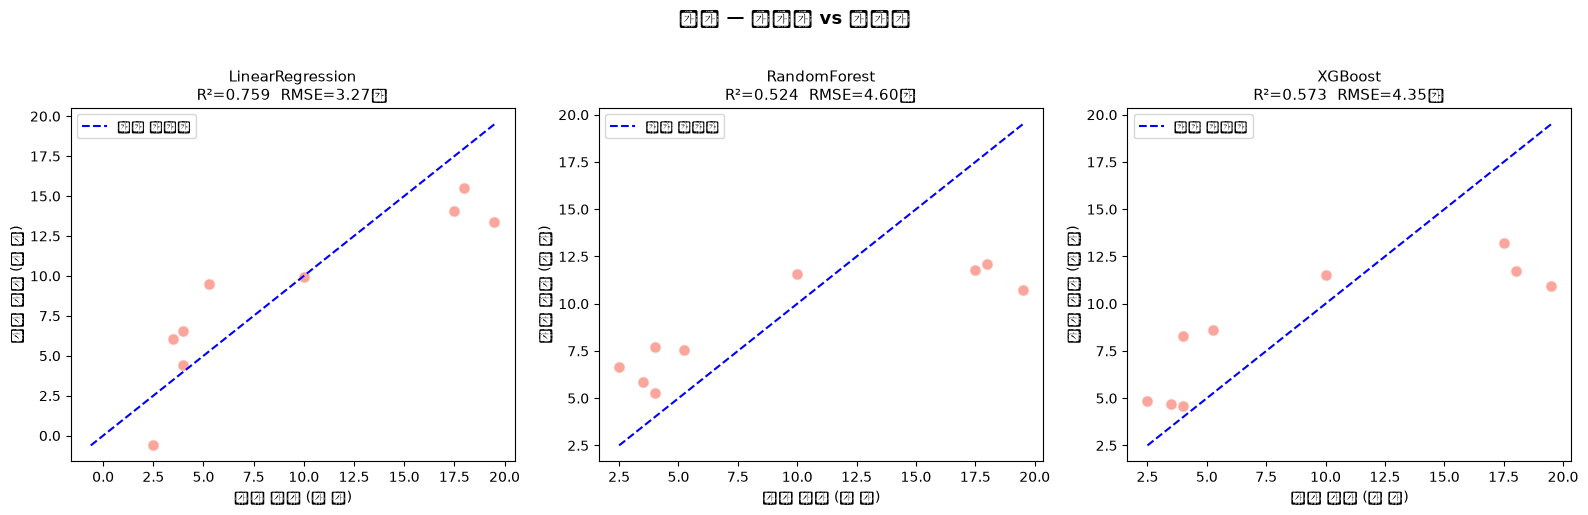

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (name, y_pred) in enumerate(preds_p.items()):
    ax = axes[i]
    ax.scatter(y_test_p, y_pred, alpha=0.7, color='salmon',
               edgecolors='white', s=70)
    mn = min(float(y_test_p.min()), float(y_pred.min()))
    mx = max(float(y_test_p.max()), float(y_pred.max()))
    ax.plot([mn, mx], [mn, mx], 'b--', lw=1.5, label='완벽 예측선')
    r2   = r2_score(y_test_p, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_p, y_pred))
    ax.set_title(f'{name}\nR²={r2:.3f}  RMSE={rmse:.2f}억', fontsize=11)
    ax.set_xlabel('실제 연봉 (억 원)')
    ax.set_ylabel('예측 연봉 (억 원)')
    ax.legend(fontsize=9)

plt.suptitle('투수 — 실제값 vs 예측값', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4-5. Feature Importance

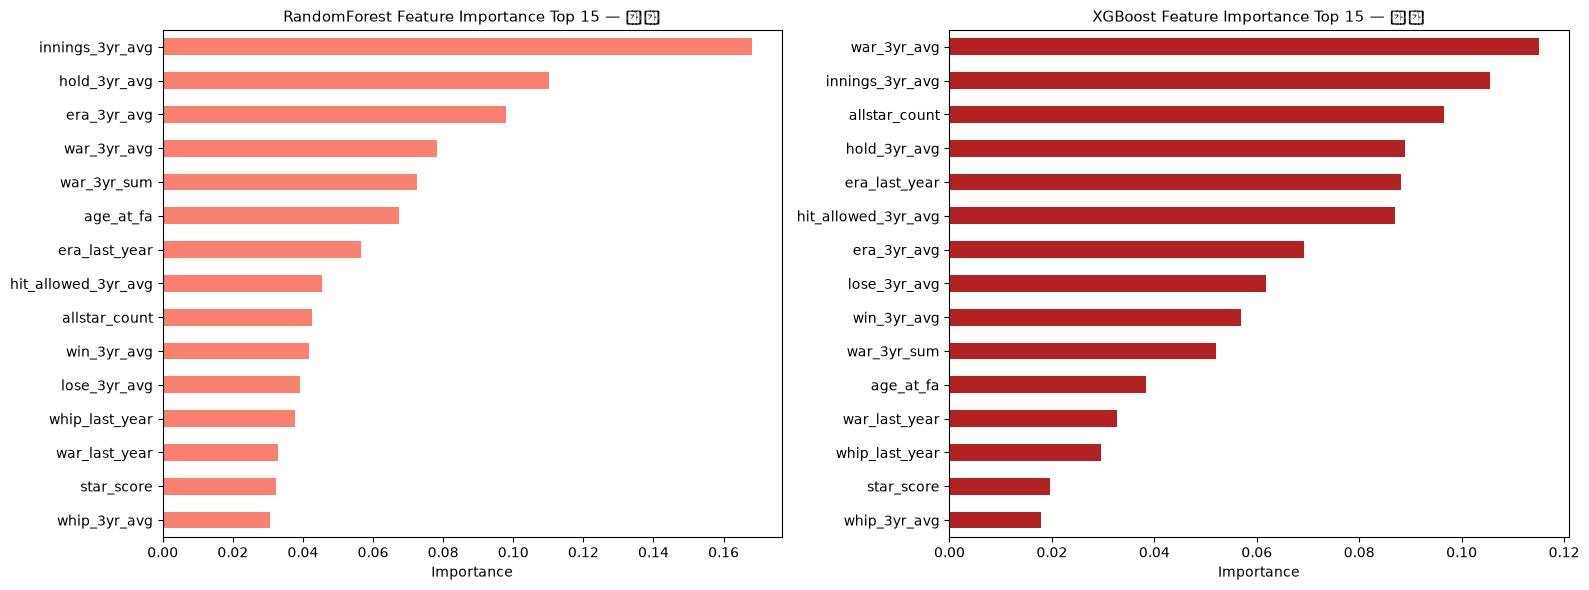

XGBoost Top 10 피처 (투수):
  war_3yr_avg                    0.1151
  innings_3yr_avg                0.1055
  allstar_count                  0.0965
  hold_3yr_avg                   0.0889
  era_last_year                  0.0882
  hit_allowed_3yr_avg            0.0869
  era_3yr_avg                    0.0692
  lose_3yr_avg                   0.0618
  win_3yr_avg                    0.0569
  war_3yr_sum                    0.0521
  age_at_fa                      0.0383
  war_last_year                  0.0327
  whip_last_year                 0.0296
  star_score                     0.0196
  whip_3yr_avg                   0.0178


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_p  = models_p['RandomForest']
xgb_p = models_p['XGBoost']

imp_rf_p = (pd.Series(rf_p.feature_importances_, index=p_final_cols)
            .sort_values(ascending=False)[:15])
imp_rf_p[::-1].plot(kind='barh', ax=axes[0], color='salmon')
axes[0].set_title('RandomForest Feature Importance Top 15 — 투수', fontsize=11)
axes[0].set_xlabel('Importance')

imp_xgb_p = (pd.Series(xgb_p.feature_importances_, index=p_final_cols)
             .sort_values(ascending=False)[:15])
imp_xgb_p[::-1].plot(kind='barh', ax=axes[1], color='firebrick')
axes[1].set_title('XGBoost Feature Importance Top 15 — 투수', fontsize=11)
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("XGBoost Top 10 피처 (투수):")
for feat, val in imp_xgb_p.items():
    print(f"  {feat:<30} {val:.4f}")

## 5. 모델 성능 비교 요약

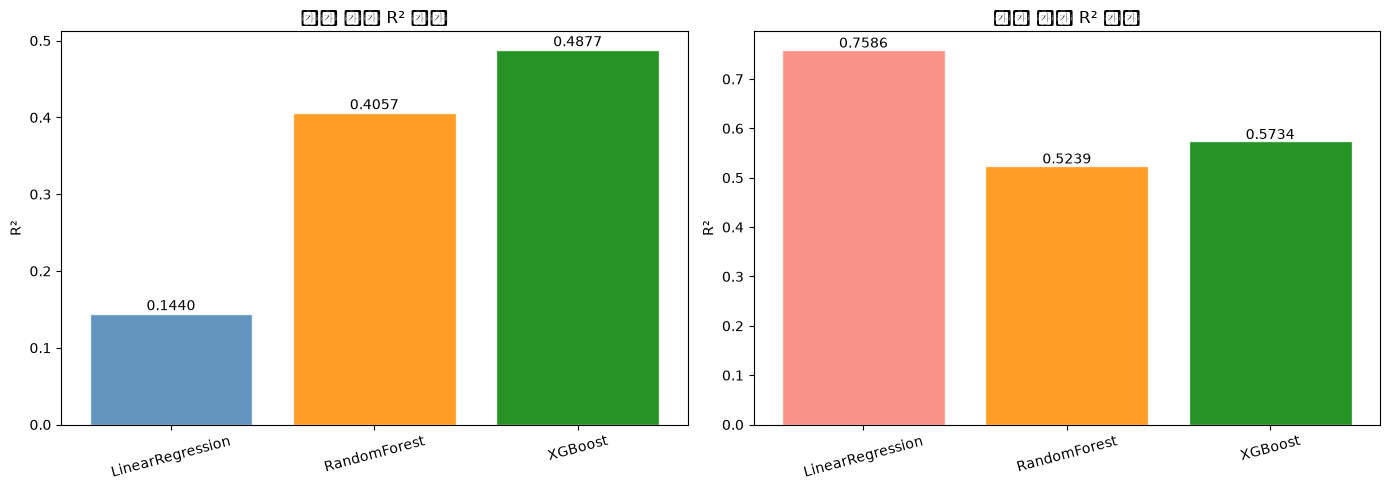

  타자 모델 성능 (R², MSE, RMSE, MAE)


,R²,MSE,RMSE,MAE
모델,,,,
LinearRegression,0.1440,50.1421,7.0811,6.0043
RandomForest,0.4057,34.8120,5.9002,4.7375
XGBoost,0.4877,30.0113,5.4783,4.2721



  투수 모델 성능 (R², MSE, RMSE, MAE)


,R²,MSE,RMSE,MAE
모델,,,,
LinearRegression,0.7586,10.7237,3.2747,2.7769
RandomForest,0.5239,21.1546,4.5994,3.9711
XGBoost,0.5734,18.9537,4.3536,3.5998


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 타자 R² 비교
r2_h = df_results_h['R²'].reset_index()
axes[0].bar(r2_h['모델'], r2_h['R²'],
            color=['steelblue', 'darkorange', 'green'], alpha=0.85, edgecolor='white')
axes[0].set_title('타자 모델 R² 비교', fontsize=12)
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(r2_h['R²']):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=10)

# 투수 R² 비교
r2_p = df_results_p['R²'].reset_index()
axes[1].bar(r2_p['모델'], r2_p['R²'],
            color=['salmon', 'darkorange', 'green'], alpha=0.85, edgecolor='white')
axes[1].set_title('투수 모델 R² 비교', fontsize=12)
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(r2_p['R²']):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("=" * 55)
print("  타자 모델 성능 (R², MSE, RMSE, MAE)")
print("=" * 55)
display(df_results_h)
print()
print("=" * 55)
print("  투수 모델 성능 (R², MSE, RMSE, MAE)")
print("=" * 55)
display(df_results_p)

## 6. 최종 모델 저장 (joblib)

R² 기준 최고 성능 모델을 `models/` 폴더에 저장합니다.

In [19]:
best_h_name = df_results_h['R²'].idxmax()
best_p_name = df_results_p['R²'].idxmax()
print(f"타자 최적 모델: {best_h_name}  (R²={df_results_h.loc[best_h_name, 'R²']})")
print(f"투수 최적 모델: {best_p_name}  (R²={df_results_p.loc[best_p_name, 'R²']})")

# 타자 저장
joblib.dump(models_h[best_h_name], MODELS / 'hitter_model.pkl')
joblib.dump(list(h_final_cols),     MODELS / 'hitter_features.pkl')
print(f"\n✅ 타자 모델 저장: models/hitter_model.pkl")
print(f"   타자 피처 저장: models/hitter_features.pkl  ({len(h_final_cols)}개)")

# 투수 저장
joblib.dump(models_p[best_p_name], MODELS / 'pitcher_model.pkl')
joblib.dump(list(p_final_cols),    MODELS / 'pitcher_features.pkl')
print(f"\n✅ 투수 모델 저장: models/pitcher_model.pkl")
print(f"   투수 피처 저장: models/pitcher_features.pkl  ({len(p_final_cols)}개)")

타자 최적 모델: XGBoost  (R²=0.4877)
투수 최적 모델: LinearRegression  (R²=0.7586)

✅ 타자 모델 저장: models/hitter_model.pkl
   타자 피처 저장: models/hitter_features.pkl  (35개)

✅ 투수 모델 저장: models/pitcher_model.pkl
   투수 피처 저장: models/pitcher_features.pkl  (23개)


In [20]:
# 로드 검증
h_loaded = joblib.load(MODELS / 'hitter_model.pkl')
h_feat   = joblib.load(MODELS / 'hitter_features.pkl')
pred_h_v = h_loaded.predict(X_test_h[h_feat])

p_loaded = joblib.load(MODELS / 'pitcher_model.pkl')
p_feat   = joblib.load(MODELS / 'pitcher_features.pkl')
pred_p_v = p_loaded.predict(X_test_p[p_feat])

print("✅ 타자 모델 로드 검증")
print(f"   실제: {list(y_test_h.values[:3])}")
print(f"   예측: {pred_h_v[:3].round(2).tolist()}")

print("\n✅ 투수 모델 로드 검증")
print(f"   실제: {list(y_test_p.values[:3])}")
print(f"   예측: {pred_p_v[:3].round(2).tolist()}")

print("\n저장된 모델 파일:")
for f in sorted(Path('../models').glob('*.pkl')):
    print(f"  {f.name}")

✅ 타자 모델 로드 검증
   실제: [np.float64(10.0), np.float64(20.0), np.float64(31.25)]
   예측: [13.369999885559082, 14.739999771118164, 16.84000015258789]

✅ 투수 모델 로드 검증
   실제: [np.float64(5.25), np.float64(4.0), np.float64(4.0)]
   예측: [9.47, 6.52, 4.41]

저장된 모델 파일:
  hitter_features.pkl
  hitter_lgb_model.pkl
  hitter_meta_model.pkl
  hitter_model.pkl
  hitter_model_meta.pkl
  hitter_rf_model.pkl
  hitter_xgb_model.pkl
  pitcher_features.pkl
  pitcher_lgb_model.pkl
  pitcher_meta_model.pkl
  pitcher_model.pkl
  pitcher_model_meta.pkl
  pitcher_rf_model.pkl
  pitcher_xgb_model.pkl


## 결론 및 한계점

### 모델 선택 근거
- **타자**: war_3yr_sum, ops_3yr_avg, woba_3yr_avg 등 성적 지표가 주요 피처
- **투수**: innings_3yr_avg, era_3yr_avg, hold_3yr_avg 등 안정성 지표가 중요
- star_score는 현재 0으로 채워져 있어, 실제 값 입력 후 재학습 시 성능 향상 기대

### 한계점
1. 표본 수 부족 (타자 80명, 투수 43명) → 과적합 위험
2. 스타성 변수 미입력 (star_score=0) → 수동 입력 필요
3. 비성적 요소 (구단 협상력, 해외 복귀 등) 미반영
4. fa_year 제거로 연봉 인플레이션 효과 일부 손실

### 개선 방향
- star_score 수동 입력 후 재학습
- 구단별 2차 보정 공식 (Streamlit 앱에서 구현)